In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [3]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
df = pd.read_csv(r"APO.csv")

# Convert Date column to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')


Using device: cuda


In [4]:
# Feature Engineering: Add Technical Indicators
df['SMA_10'] = df['Close_Prices'].rolling(window=10).mean()
df['EMA_10'] = df['Close_Prices'].ewm(span=10, adjust=False).mean()
df['RSI'] = 100 - (100 / (1 + (df['Close_Prices'].pct_change().rolling(14).mean() / 
                               df['Close_Prices'].pct_change().rolling(14).std())))
df['MACD'] = df['Close_Prices'].ewm(span=12, adjust=False).mean() - df['Close_Prices'].ewm(span=26, adjust=False).mean()
df['Bollinger_High'] = df['Close_Prices'].rolling(20).mean() + (df['Close_Prices'].rolling(20).std() * 2)
df['Bollinger_Low'] = df['Close_Prices'].rolling(20).mean() - (df['Close_Prices'].rolling(20).std() * 2)

df.dropna(inplace=True)

features = ['Close_Prices', 'Open_Prices', 'High_Prices', 'Low_Prices', 'Volume', 
            'SMA_10', 'EMA_10', 'RSI', 'MACD', 'Bollinger_High', 'Bollinger_Low']

train_data = df[df['Date'] < '2024-01-01']
test_data = df[df['Date'] >= '2024-01-01']


In [ ]:
# Normalize Data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data[features])
test_scaled = scaler.transform(test_data[features])

# Function to create sequences
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length][0])  # Predicting Close Price
    return np.array(sequences), np.array(labels)

SEQ_LENGTH = 120
X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

# Convert to PyTorch tensors and move to GPU
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1).to(device)

In [6]:
# Define LSTM Model
class StockLSTM(nn.Module):
    def __init__(self, input_size=11, hidden_size=512, num_layers=2, output_size=1):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

# Initialize Model and Move to GPU
model = StockLSTM().to(device)

# Define loss function and optimizer
criterion = nn.L1Loss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Train the Model
EPOCHS = 150
early_stop_threshold = 10  # Stop if no improvement for 5 epochs
min_loss = float('inf')
no_improve_count = 0

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}")

    # Early stopping condition
    if loss.item() < min_loss:
        min_loss = loss.item()
        no_improve_count = 0
    else:
        no_improve_count += 1

    if no_improve_count >= early_stop_threshold:
        print(f"Early stopping at epoch {epoch + 1}")
        break

# Make Predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).detach().cpu().numpy()

# Convert predictions and actual values back to original scale
predictions = scaler.inverse_transform(
    np.concatenate([predictions, np.zeros((predictions.shape[0], 10))], axis=1)
)[:, 0]

actual_prices = scaler.inverse_transform(
    np.concatenate([y_test.cpu().numpy(), np.zeros((y_test.shape[0], 10))], axis=1)
)[:, 0]

Epoch [10/150], Loss: 0.1810
Epoch [20/150], Loss: 0.1358
Epoch [30/150], Loss: 0.0589
Epoch [40/150], Loss: 0.0410
Epoch [50/150], Loss: 0.0254
Epoch [60/150], Loss: 0.0178
Epoch [70/150], Loss: 0.0151
Epoch [80/150], Loss: 0.0136
Epoch [90/150], Loss: 0.0132
Epoch [100/150], Loss: 0.0128
Epoch [110/150], Loss: 0.0128
Epoch [120/150], Loss: 0.0124
Epoch [130/150], Loss: 0.0124
Early stopping at epoch 137



Root Mean Squared Error (RMSE): 9.5657
Mean Absolute Error (MAE): 8.0848
R-squared Score (R²): 0.8494

Final Portfolio Value: $1739.99
Total Profit: $739.99
Return on Investment (ROI): 74.00%


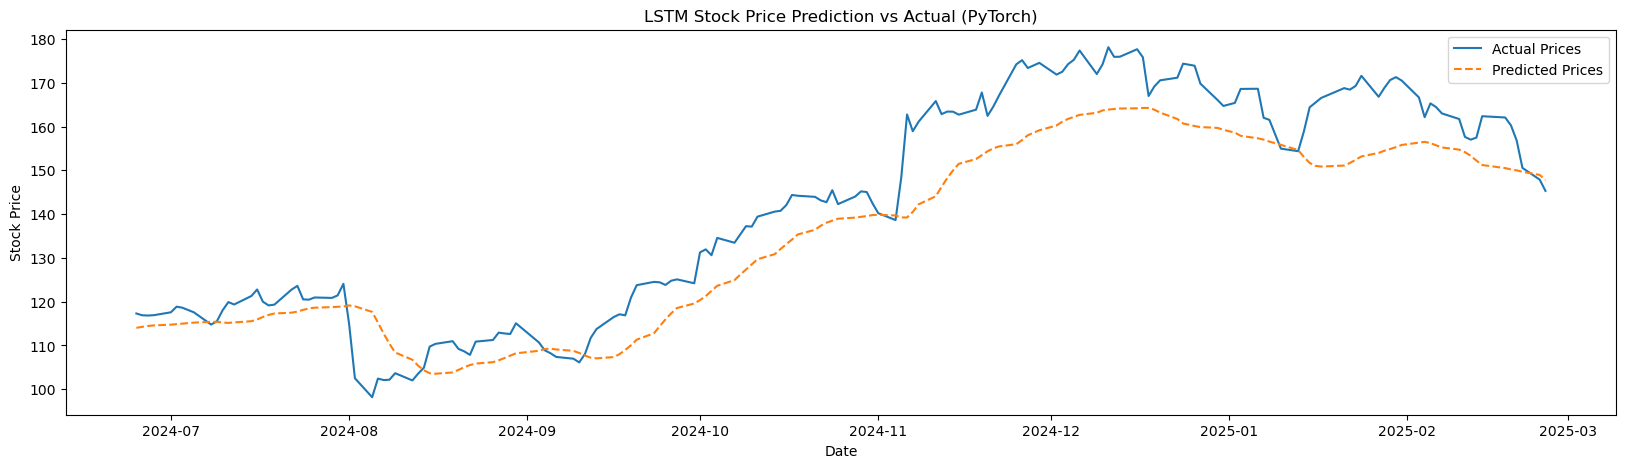

In [7]:
# Evaluate Model Performance
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))
mae = mean_absolute_error(actual_prices, predictions)
r2 = r2_score(actual_prices, predictions)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

# Simulate Trading Strategy with $1000 Initial Capital
initial_capital = 1000
capital = initial_capital
shares = 0  

for i in range(len(predictions) - 1):  
    predicted_price_today = predictions[i]
    predicted_price_next_day = predictions[i + 1]

    if predicted_price_next_day > predicted_price_today:
        shares_to_buy = capital // predicted_price_today
        capital -= shares_to_buy * predicted_price_today
        shares += shares_to_buy
    elif predicted_price_next_day < predicted_price_today and shares > 0:
        capital += shares * predicted_price_today
        shares = 0

final_value = capital + (shares * predictions[-1])
profit = final_value - initial_capital

print(f"\nFinal Portfolio Value: ${final_value:.2f}")
print(f"Total Profit: ${profit:.2f}")
print(f"Return on Investment (ROI): {((final_value / initial_capital) - 1) * 100:.2f}%")

# Plot Predictions vs. Actual Prices
plt.figure(figsize=(20, 5))
plt.plot(df['Date'][-len(actual_prices):], actual_prices, label="Actual Prices")
plt.plot(df['Date'][-len(predictions):], predictions, label="Predicted Prices", linestyle='dashed')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("LSTM Stock Price Prediction vs Actual (PyTorch)")
plt.show()